In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Trade Strategy 20250603

## Description
Combine various individual strategies and assets to create a portfolio.

## Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from utils.data_fetcher import TickerPriceDataFetcher
import os
from indicators.volatility import calculate_atr, calculate_forward_vol
from indicators.returns import calculate_returns, calculate_forward_returns, calculate_MA_returns, calculate_relative_volume
from utils.helpers import PercentileScaler
import datetime
from sklearn.linear_model import LinearRegression
from utils.backtester import BackTester
import backtrader as bt
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from pypfopt.hierarchical_portfolio import HRPOpt
from pypfopt.plotting import plot_dendrogram
from pypfopt import risk_models
from scipy import stats
from scipy.stats import linregress



## Utils

### Helpers

In [13]:
def normalize_weights(weights):
    total_weight = sum(weights.values())
    normalized_weights = {ticker: weight / total_weight for ticker, weight in weights.items()}
    return normalized_weights

def gmean(arr):
    return np.exp(np.mean(np.log(arr)))

def hmean(arr):
    return 1 / np.mean(1 / arr)


def compute_r2(y):
    x = range(len(y))
    result = linregress(x, y)
    r_squared = result.rvalue ** 2
    return r_squared

## Parameters

In [14]:
lookforward_period = 50
lookback_periods=[21, 50, 100, 200, 252]

rebalance_period = 21
atr_period = 21
covariance_matrix_lookback = 252
historical_lookback_period = 252 * 2
vol_target = 0.1
current_date = datetime.datetime.now().date()
current_date = current_date.strftime("%Y%m%d")

tickers_to_fetch = ['IB01.L', 'SHV', 'SPY', 'TLT', 'GLD', '^VIX', '^GVZ', 'PPLT', 'URA', 'DBA', 'EEM', 'LQD', 'IBIT', 'USO']
tickers_to_trade = [
    'SPY', 
    # 'TLT', 
    'GLD', 
    # '^VIX', 
    # '^GVZ', 
    'PPLT', 
    'URA', 
    'DBA', 
    'EEM', 
    'LQD', 
    'IBIT', 
    'USO'
]

## Load Data

In [15]:
fetcher = TickerPriceDataFetcher()
price_data = fetcher.load_data(ticker_list=tickers_to_fetch)

for ticker in price_data:
    print(ticker, price_data[ticker].index.to_list()[0], price_data[ticker].index.to_list()[-1])
    # display(price_data[ticker])


2025-07-09 20:59:01,997 - utils.data_fetcher - INFO - Loading data for ['IB01.L', 'SHV', 'SPY', 'TLT', 'GLD', '^VIX', '^GVZ', 'PPLT', 'URA', 'DBA', 'EEM', 'LQD', 'IBIT', 'USO']
2025-07-09 20:59:01,998 - utils.data_fetcher - INFO - Data for IB01.L already exists
2025-07-09 20:59:02,008 - utils.data_fetcher - INFO - Data for SHV already exists
2025-07-09 20:59:02,018 - utils.data_fetcher - INFO - Data for SPY already exists
2025-07-09 20:59:02,026 - utils.data_fetcher - INFO - Data for TLT already exists
2025-07-09 20:59:02,036 - utils.data_fetcher - INFO - Data for GLD already exists
2025-07-09 20:59:02,045 - utils.data_fetcher - INFO - Data for ^VIX already exists
2025-07-09 20:59:02,054 - utils.data_fetcher - INFO - Data for ^GVZ already exists
2025-07-09 20:59:02,064 - utils.data_fetcher - INFO - Data for PPLT already exists
2025-07-09 20:59:02,075 - utils.data_fetcher - INFO - Data for URA already exists
2025-07-09 20:59:02,084 - utils.data_fetcher - INFO - Data for DBA already exis

IB01.L 2019-02-20 00:00:00 2025-07-09 00:00:00
SHV 2007-01-11 00:00:00 2025-07-08 00:00:00
SPY 1993-01-29 00:00:00 2025-07-08 00:00:00
TLT 2002-07-30 00:00:00 2025-07-08 00:00:00
GLD 2004-11-18 00:00:00 2025-07-08 00:00:00
^VIX 1990-01-02 00:00:00 2025-07-09 00:00:00
^GVZ 2008-06-03 00:00:00 2025-07-08 00:00:00
PPLT 2010-01-08 00:00:00 2025-07-08 00:00:00
URA 2010-11-05 00:00:00 2025-07-08 00:00:00
DBA 2007-01-05 00:00:00 2025-07-08 00:00:00
EEM 2003-04-14 00:00:00 2025-07-08 00:00:00
LQD 2002-07-30 00:00:00 2025-07-08 00:00:00
IBIT 2024-01-11 00:00:00 2025-07-08 00:00:00
USO 2006-04-10 00:00:00 2025-07-08 00:00:00


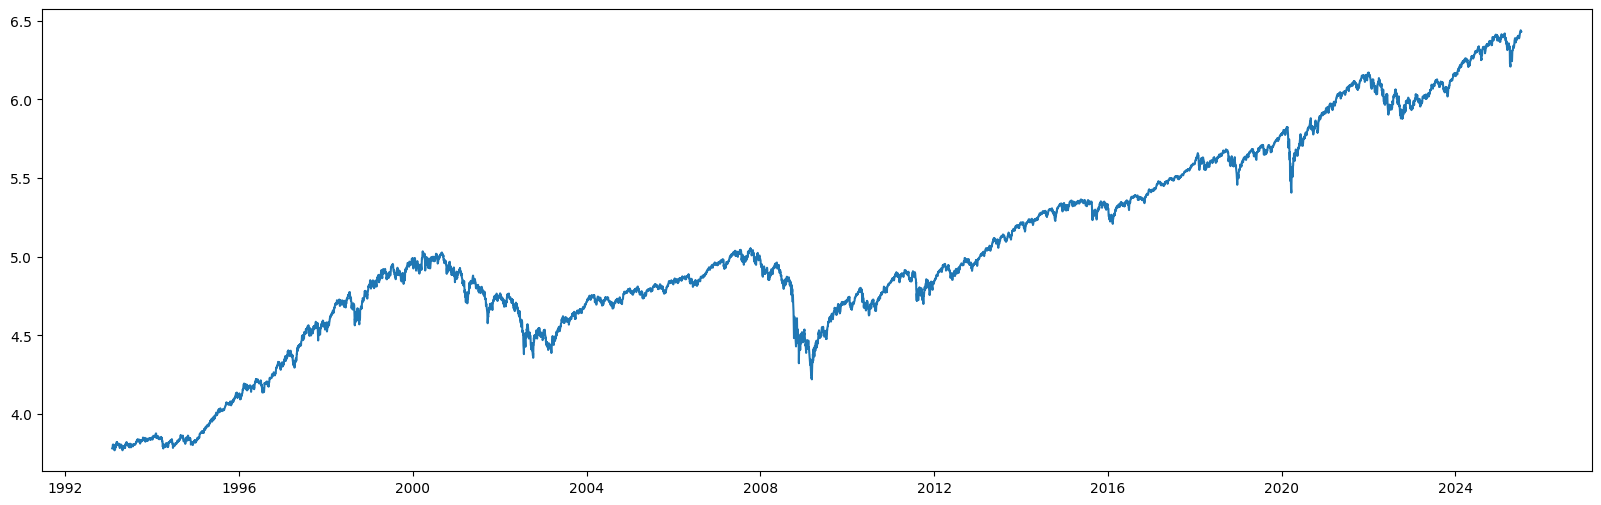

In [16]:
df = price_data['SPY'].copy()
df['log_close'] = np.log(df['close'])

plt.figure(figsize=(20, 6))
plt.plot(df['log_close'])
plt.show()

## Process Data

In [17]:
def process_price_data(df, lookforward_period=21, atr_period=21, lookback_periods=[21, 100, 200, 252], vix_ticker=None):
    # Calculate indicators
    df['returns'] = df['close'].pct_change()
    df['vol_forward'] = calculate_forward_vol(df, lookforward_period)
    df['ret_forward'] = calculate_forward_returns(df, lookforward_period)
    df['ATR'] = calculate_atr(df, atr_period)
    df['var_forward'] = df['vol_forward'] ** 2
    if vix_ticker is not None:
        df['VIX'] = price_data[vix_ticker]['close'].copy()
    for period in lookback_periods:
        df['MA_{}'.format(period)] = calculate_MA_returns(df, period)
    df['high_breakout_21'] = (df['close'] - df['close'].rolling(21).max().shift(1)) / df['close']
    df['low_breakout_21'] = (df['close'] - df['close'].rolling(21).min().shift(1)) / df['close']
    df['high_breakout_252'] = (df['close'] - df['close'].rolling(252).max().shift(1)) / df['close']
    df['low_breakout_252'] = (df['close'] - df['close'].rolling(252).min().shift(1)) / df['close']


    def compute_r2_signal(y):
        return compute_r2(np.log(y))

    df['r2_21'] = df['close'].rolling(21).apply(compute_r2_signal)
    df['r2_252'] = df['close'].rolling(252).apply(compute_r2_signal)

    df['ret_21_r2_adj'] = calculate_returns(df, 21) * df['r2_21']
    df['ret_252_r2_adj'] = calculate_returns(df, 252) * df['r2_252']

    df['relative_volume'] = calculate_relative_volume(df, 20, 50)
    return df


risky_assets = dict()

# SPY - US equities
risky_assets['SPY'] = dict()
df = price_data['SPY'].copy()
risky_assets['SPY']['data'] = process_price_data(
    df, 
    vix_ticker='^VIX',
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
print('SPY')
display(risky_assets['SPY']['data'])

# TLT - US treasury bonds
risky_assets['TLT'] = dict()
df = price_data['TLT'].copy()
risky_assets['TLT']['data'] = process_price_data(
    df,
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
print('TLT')
display(risky_assets['TLT']['data'])

# GLD - Gold
risky_assets['GLD'] = dict()
df = price_data['GLD'].copy()
risky_assets['GLD']['data'] = process_price_data(
    df, 
    # vix_ticker='^GVZ',
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
print('GLD')
display(risky_assets['GLD']['data'])

# EEM - Emerging markets
risky_assets['EEM'] = dict()
df = price_data['EEM'].copy()
risky_assets['EEM']['data'] = process_price_data(
    df,
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
print('EEM')
display(risky_assets['EEM']['data'])

# DBA - Agriculture
risky_assets['DBA'] = dict()
df = price_data['DBA'].copy()
risky_assets['DBA']['data'] = process_price_data(
    df,
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
print('DBA')
display(risky_assets['DBA']['data'])

# LQD - US corporate bonds
risky_assets['LQD'] = dict()
df = price_data['LQD'].copy()
risky_assets['LQD']['data'] = process_price_data(
    df,
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
print('LQD')
display(risky_assets['LQD']['data'])

# IBIT - Bitcoin
risky_assets['IBIT'] = dict()
df = price_data['IBIT'].copy()
risky_assets['IBIT']['data'] = process_price_data(
    df,
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
print('IBIT')
display(risky_assets['IBIT']['data'])

# PPLT - platinum
risky_assets['PPLT'] = dict()
df = price_data['PPLT'].copy()
risky_assets['PPLT']['data'] = process_price_data(
    df,
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
print('PPLT')
display(risky_assets['PPLT']['data'])

# URA - uranium
risky_assets['URA'] = dict()
df = price_data['URA'].copy()
risky_assets['URA']['data'] = process_price_data(
    df,
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods
)
print('URA')
display(risky_assets['URA']['data'])

# USO - oil
risky_assets['USO'] = dict()
df = price_data['USO'].copy()
risky_assets['USO']['data'] = process_price_data(
    df,
    lookforward_period=lookforward_period,
    atr_period=atr_period,
    lookback_periods=lookback_periods,
)
print('USO')
display(risky_assets['USO']['data'])



SPY


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,...,MA_252,high_breakout_21,low_breakout_21,high_breakout_252,low_breakout_252,r2_21,r2_252,ret_21_r2_adj,ret_252_r2_adj,relative_volume
Date,,,,,,,,,,,,,,,,,,,,,
1993-01-29,43.968750,43.968750,43.750000,43.937500,24.380447,1003200,0.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-01,43.968750,44.250000,43.968750,44.250000,24.553843,480500,0.0,0.0,0.0,0.007112,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-02,44.218750,44.375000,44.125000,44.343750,24.605865,201300,0.0,0.0,0.0,0.002119,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-03,44.406250,44.843750,44.375000,44.812500,24.865967,529400,0.0,0.0,0.0,0.010571,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-04,44.968750,45.093750,44.468750,45.000000,24.970011,531500,0.0,0.0,0.0,0.004184,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-01,616.359985,618.830017,615.520020,617.650024,617.650024,70030100,0.0,0.0,0.0,-0.000324,...,0.073702,-0.000324,0.045754,-0.000324,0.196179,0.641285,0.113601,0.026984,0.015328,1.068873
2025-07-02,617.239990,620.489990,616.609985,620.450012,620.450012,66510400,0.0,0.0,0.0,0.004533,...,0.078003,0.004191,0.044709,0.004191,0.199807,0.661904,0.115222,0.027050,0.015870,1.071808
2025-07-03,622.450012,626.280029,622.429993,625.340027,625.340027,51065800,0.0,0.0,0.0,0.007881,...,0.085900,0.007820,0.051636,0.007820,0.206064,0.700718,0.117474,0.034581,0.016333,1.074974


TLT


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,...,MA_252,high_breakout_21,low_breakout_21,high_breakout_252,low_breakout_252,r2_21,r2_252,ret_21_r2_adj,ret_252_r2_adj,relative_volume
Date,,,,,,,,,,,,,,,,,,,,,
2002-07-30,81.750000,81.900002,81.519997,81.519997,37.468719,6100,0.000,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-07-31,81.949997,82.800003,81.900002,82.529999,37.932957,29400,0.000,0.0,0.0,0.012390,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-08-01,82.540001,83.019997,82.540001,83.000000,38.148972,25000,0.000,0.0,0.0,0.005695,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-08-02,83.160004,84.099998,82.879997,83.849998,38.539627,52800,0.000,0.0,0.0,0.010241,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-08-05,84.040001,84.440002,83.849998,84.220001,38.709728,61100,0.000,0.0,0.0,0.004413,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-01,88.129997,88.309998,87.660004,88.139999,88.139999,38960600,0.328,0.0,0.0,-0.001246,...,-0.033831,-0.001248,0.035512,-0.149648,0.047311,0.736695,0.605381,0.025779,-0.024009,1.015871
2025-07-02,87.190002,87.589996,87.099998,87.580002,87.580002,39382200,0.000,0.0,0.0,-0.006354,...,-0.039794,-0.007650,0.029345,-0.156999,0.041219,0.708842,0.611252,0.021430,-0.015840,1.023238
2025-07-03,87.169998,87.290001,86.849998,86.970001,86.970001,26729100,0.000,0.0,0.0,-0.006965,...,-0.046360,-0.014718,0.022536,-0.165114,0.034495,0.601937,0.623050,0.004041,-0.025029,0.986087


GLD


...

,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,...,MA_252,high_breakout_21,low_breakout_21,high_breakout_252,low_breakout_252,r2_21,r2_252,ret_21_r2_adj,ret_252_r2_adj,relative_volume
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-08,158.070007,160.000000,155.800003,159.000000,159.000000,414700,0.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-11,160.949997,165.000000,159.149994,160.210007,160.210007,234600,0.0,0.0,0.0,0.007610,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-12,159.039993,160.389999,155.080002,157.160004,157.160004,435700,0.0,0.0,0.0,-0.019038,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-13,157.240005,158.149994,155.600006,158.029999,158.029999,367000,0.0,0.0,0.0,0.005536,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-14,160.130005,161.850006,159.720001,161.449997,161.449997,228500,0.0,0.0,0.0,0.021641,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-01,123.230003,124.000000,121.260002,123.519997,123.519997,433200,0.0,0.0,0.0,0.005290,...,0.358783,-0.043232,0.216726,-0.043232,0.330797,0.856236,0.227669,0.228394,0.079772,1.592383
2025-07-02,126.269997,130.639999,126.059998,130.160004,130.160004,950800,0.0,0.0,0.0,0.053757,...,0.429413,0.009988,0.250845,0.009988,0.364935,0.858705,0.239617,0.276582,0.107578,1.602260
2025-07-03,125.230003,125.940002,123.870003,125.139999,125.139999,433600,0.0,0.0,0.0,-0.038568,...,0.372172,-0.040115,0.213281,-0.040115,0.339460,0.843131,0.250585,0.206609,0.091753,1.587817


URA


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,...,MA_252,high_breakout_21,low_breakout_21,high_breakout_252,low_breakout_252,r2_21,r2_252,ret_21_r2_adj,ret_252_r2_adj,relative_volume
Date,,,,,,,,,,,,,,,,,,,,,
2010-11-05,103.440002,103.440002,99.480003,103.260002,69.925392,48233,0.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-11-08,104.699997,114.779999,103.919998,114.779999,77.726486,255017,0.0,0.0,0.0,0.111563,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-11-09,116.160004,119.519997,109.800003,111.000000,75.166771,334967,0.0,0.0,0.0,-0.032933,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-11-10,111.959999,113.099998,108.000000,112.739998,76.345039,121967,0.0,0.0,0.0,0.015676,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-11-11,114.000000,114.120003,111.120003,113.699997,76.995140,111767,0.0,0.0,0.0,0.008515,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-01,38.349998,38.419998,37.270000,37.419998,37.419998,3018200,0.0,0.0,0.0,-0.035816,...,0.320765,-0.037146,0.148316,-0.037146,0.458578,0.838925,0.007357,0.146095,0.002152,1.144537
2025-07-02,37.500000,37.779999,37.020000,37.709999,37.709999,2594300,0.0,0.0,0.0,0.007750,...,0.329370,-0.029170,0.154866,-0.029170,0.462742,0.783300,0.010365,0.118906,0.003048,1.110148
2025-07-03,37.860001,38.209999,37.230000,37.900002,37.900002,1409900,0.0,0.0,0.0,0.005039,...,0.334433,-0.024011,0.136148,-0.024011,0.465435,0.724658,0.013926,0.105588,0.004337,1.096931


USO


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,...,MA_252,high_breakout_21,low_breakout_21,high_breakout_252,low_breakout_252,r2_21,r2_252,ret_21_r2_adj,ret_252_r2_adj,relative_volume
Date,,,,,,,,,,,,,,,,,,,,,
2006-04-10,546.000000,548.000000,541.359985,544.159973,544.159973,484738,0.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-04-11,546.559998,547.119995,538.400024,545.599976,545.599976,162138,0.0,0.0,0.0,0.002646,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-04-12,545.760010,550.479980,542.479980,542.719971,542.719971,156038,0.0,0.0,0.0,-0.005279,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-04-13,540.000000,551.919983,539.200012,550.559998,550.559998,70088,0.0,0.0,0.0,0.014446,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-04-17,553.599976,559.200012,549.440002,558.320007,558.320007,114713,0.0,0.0,0.0,0.014095,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-01,73.610001,74.040001,73.320000,73.930000,73.930000,4425200,0.0,0.0,0.0,0.011216,...,0.004626,-0.124307,0.091708,-0.140809,0.156364,0.160077,0.141394,0.010081,-0.010055,1.661725
2025-07-02,74.320000,76.019997,73.510002,75.589996,75.589996,6491400,0.0,0.0,0.0,0.022454,...,0.027405,-0.099616,0.082683,-0.115756,0.174891,0.106511,0.132896,0.008687,-0.009698,1.660319
2025-07-03,75.410004,75.919998,74.879997,75.190002,75.190002,4394800,0.0,0.0,0.0,-0.005292,...,0.022319,-0.105466,0.077803,-0.121692,0.170501,0.054879,0.123695,0.004630,-0.009028,1.649671


## Define Strategy

In [47]:
leverage_tracker = []
allocation_tracker = []


def allocation_func(
    ticker_list, 
    lookback_periods, 
    historical_period, 
    current_date,
    dict_data,
    covariance_matrix_lookback,
    verbose=False
):
    #################################################################
    # Compute Asset-level allocation using Hierarchical Risk Parity 
    #################################################################
    if len(ticker_list) > 1:
        
        df_combined = pd.DataFrame()
        for ticker in ticker_list:
            df_data = dict_data[ticker].copy()
            df_data = df_data[df_data.index <= current_date].copy()
            df_data = df_data.iloc[-historical_period:]
            df_data['returns'] = df_data['close'].pct_change()
            df_combined[ticker] = df_data['returns']
        
        df_combined.dropna(inplace=True)
        

        # Covariance Matrix with Exponentially Weighted Moving Average
        ewma_cov = risk_models.exp_cov(df_combined, returns_data=True, span=covariance_matrix_lookback)

        # Convariance Matrix with Ledoit Wolf shrinkage
        ledoit_wolf_cov = risk_models.CovarianceShrinkage(
            prices=df_combined.iloc[-covariance_matrix_lookback:], 
            returns_data=True
        ).ledoit_wolf()

        # Final Covariance Matrix is mean of EWMA and Ledoit Wolf
        cov = (ledoit_wolf_cov + ewma_cov) / 2

        # HRP to generate asset allocation weights
        hrpopt = HRPOpt(
            cov_matrix=cov
        )
        asset_allocation_weights = hrpopt.optimize()

        # Limit weights to be between 5% and 50%
        for ticker in ticker_list:
            asset_allocation_weights[ticker] = np.clip(asset_allocation_weights[ticker], 0.05, 0.5)
            # asset_allocation_weights[ticker] = 1
            
    else:
        # Single asset case
        asset_allocation_weights = {ticker_list[0]: 1}
    

    #################################################################
    # Compute Strategy Allocations
    #################################################################
    allocation_tracker.append(dict())
    for ticker in ticker_list:

        # Limit data to current date
        df_data = dict_data[ticker]
        df_data = df_data[df_data.index <= current_date].copy()
        
        # Limit date to lookback period
        df_data = df_data.iloc[-historical_period:]
        
        # Forecast forward returns and volatility
        # Define features
        X_features = [f'MA_{period}' for period in lookback_periods]
        X_features += ['ATR']
        if 'VIX' in df_data.columns:
            X_features += ['VIX']
        X_features += ['high_breakout_21', 'low_breakout_21', 'high_breakout_252', 'low_breakout_252']
        X_features += ['r2_21', 'r2_252']
        X_features += ['ret_21_r2_adj', 'ret_252_r2_adj']
        X_features += ['relative_volume']

        df_train = df_data[X_features + ['ret_forward', 'vol_forward']].copy()
        df_train = df_train.dropna()
        # df_train = df_train[:-10]
        X_scaler = RobustScaler()
        df_train[X_features] = X_scaler.fit_transform(df_train[X_features])
        X_train = df_train[X_features].iloc[:-1]
        X_test =  df_data[X_features].iloc[-1:]
        X_test = pd.DataFrame(X_test, columns=X_features)
        X_test[X_features] = X_scaler.transform(X_test)
        
        if verbose:
            display(ticker)
            display(X_test)


        #########################
        # Vol Forecast
        # Vol scaling factor computation logic:
        #########################
        y_train = df_train['vol_forward'].iloc[:-1]
        model = LinearRegression()
        model.fit(X_train, y_train)
        vol_forecast = model.predict(X_test)[0]

        # Transform vol forecast to be between 0 and 1 as percentile of vol distribution
        # Higher vol forecast = lower vol scaling factor
        pct_rank = stats.percentileofscore(y_train, vol_forecast, kind='rank') / 100
        vol_scaling_factor = (1 - pct_rank) * 1.0

        # Constraint vol scaling factor to be between 0.1 and 1
        vol_scaling_factor = np.clip(vol_scaling_factor, 0.1, 1.0)

        # Record model performance
        y_pred = vol_forecast
        y_true = df_data['vol_forward'].iloc[-1]


        #########################
        # Ret Forecast
        #########################

        ret_scaling_factors = []
        
        # Price - MA
        for period in lookback_periods:
            if df_data[f'MA_{period}'].iloc[-1] > 0:
                ret_scaling_factors.append(1)
            else:
                ret_scaling_factors.append(0.05)
        
        # Returns
        for period in [21, 252]:
            if df_data[f'ret_{period}_r2_adj'].iloc[-1] > 0:
                ret_scaling_factors.append(1)
            else:
                ret_scaling_factors.append(0.05)
        
        # R2
        for period in [21, 252]:
            X_ref = df_data[f'ret_{period}_r2_adj'].to_list()[:-1]
            X_ref = [f for f in X_ref if f > 0]
            x_current = df_data[f'ret_{period}_r2_adj'].iloc[-1]
            if x_current > 0:
                pct_rank = stats.percentileofscore(X_ref, x_current, kind='rank') / 100
                ret_scaling_factors.append(pct_rank)
            else:
                ret_scaling_factors.append(0.05)
        
        # R2
        for period in [21, 252]:
            if df_data[f'ret_{period}_r2_adj'].iloc[-1] > 0:
                ret_scaling_factors.append(df_data[f'r2_{period}'].iloc[-1])
            else:
                ret_scaling_factors.append(0.05)


            
        ret_scaling_factor = np.mean(ret_scaling_factors)
        if verbose:
            print(ticker, ret_scaling_factors, ret_scaling_factor)
        
        # Scaling factor is the geometric mean of ret_scaling_factor and vol_scaling_factor
        # We maintain the sign of the scaling factor.
        sign = 1
        if ret_scaling_factor < 0:
            sign = -1
        scaling_factor = gmean(np.abs(np.array([ret_scaling_factor, vol_scaling_factor]))) * sign
        
        
        # Final allocation = asset_level_weights * strategy_level_weights
        asset_allocation_weights[ticker] = asset_allocation_weights[ticker] * scaling_factor
        asset_allocation_weights[ticker] = ret_scaling_factor
    

    # sum_allocation = np.sum([np.abs(f) for f in asset_allocation_weights.values()])
    # for ticker in ticker_list:
    #     asset_allocation_weights[ticker] = asset_allocation_weights[ticker] / sum_allocation
    #     if np.abs(asset_allocation_weights[ticker]) < 0.05:
    #         asset_allocation_weights[ticker] = 0
    
    leverage_tracker.append(sum(asset_allocation_weights.values()))
    return asset_allocation_weights
    


In [48]:
from strategies.base import BaseStrategy

ret_model_perf_tracker = []
vol_model_perf_tracker = []
leverage_tracker = []

class MultiAssetStrategy(BaseStrategy):

    params = (
        ('rebalance_period', 21),
        ('lookback_periods', [21, 100, 200, 252]),
        ('dict_data', dict()),
        ('historical_period', 252*2),
        ('covariance_matrix_lookback', 252),
    )

    def __init__(self):
        super().__init__()

        # Track rebalance interval
        self.rebalance_day = 0

        self.dict_data = self.p.dict_data
        
        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            self.rebalance()
        
        
        self.rebalance_day += 1


    def rebalance(self):
        current_capital = self.broker.getvalue()
        current_date = pd.to_datetime(self.datetime.date())

        

            
        
        # leverage_tracker.append(sum(asset_allocation_weights.values()))
        asset_allocation_weights = allocation_func(
            ticker_list=self.p.tickers, 
            lookback_periods=self.p.lookback_periods, 
            historical_period=self.p.historical_period, 
            current_date=current_date,
            dict_data=self.p.dict_data,
            covariance_matrix_lookback=self.p.covariance_matrix_lookback,
            # verbose=True
        )
        for ticker in self.p.tickers:

            
            data = self.getdatabyname(ticker)
            current_position = self.broker.getposition(data).size
            ticker_capital = current_capital * asset_allocation_weights[ticker]
            
            target_position = ticker_capital / self.data.close[0]
            # Submit order
            self._submit_order(ticker, target_position - current_position, self.data.close[0])




## Run Backtest

cagr: 0.06
volatility: 0.10
sharpe: 0.62
max_drawdown: 0.20
cumulative_returns: 2.09
Mean leverage: 0.62


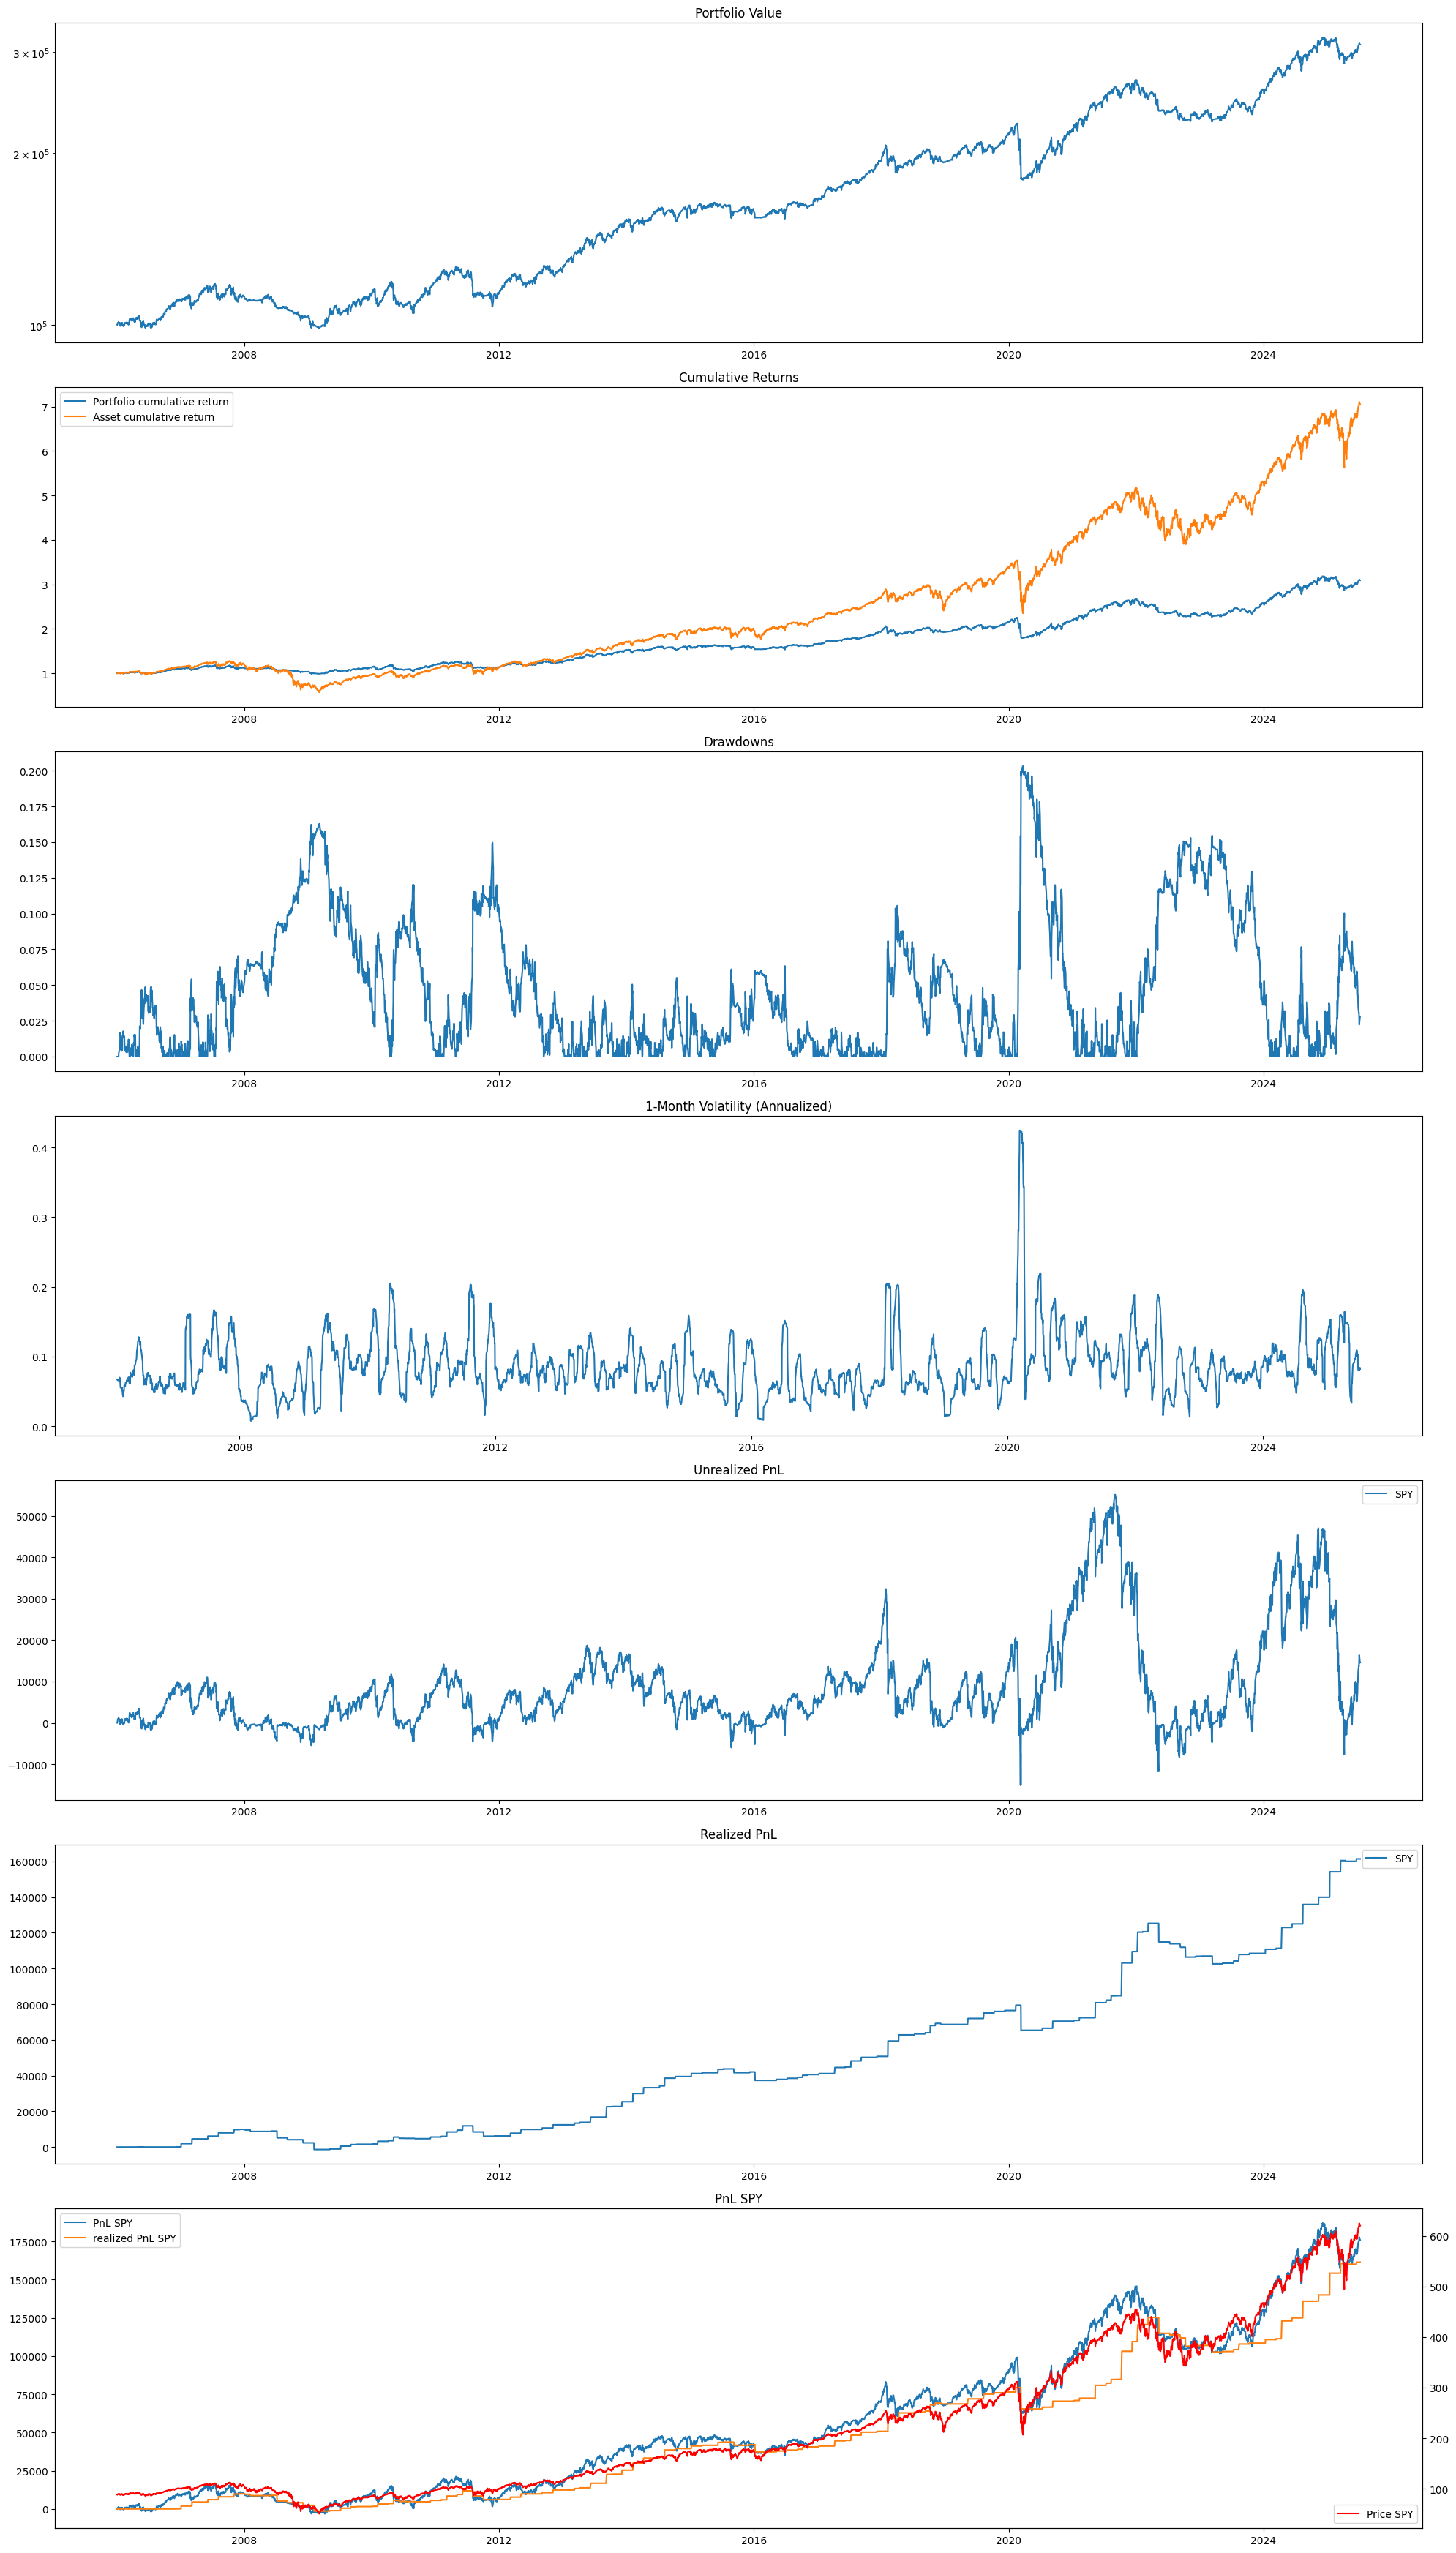

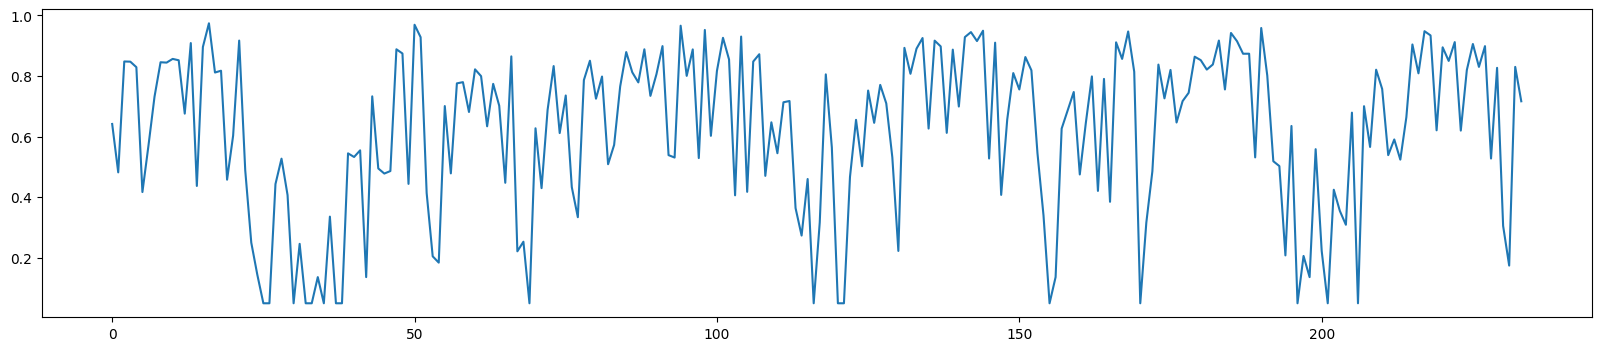

In [49]:
tickers_in_backtest = [
    'SPY', 
    # 'TLT', 
    # 'GLD', 
    # 'PPLT', 
    # 'URA', 
    # 'DBA', 
    # 'EEM',
    # 'LQD', 
    # 'IBIT',
    # 'USO',
]


ret_model_perf_tracker = []
vol_model_perf_tracker = []
leverage_tracker = []

# Price data
trading_price_data = {f: price_data[f].copy() for f in tickers_in_backtest}
start_date = pd.to_datetime('2006-01-01')
for ticker in trading_price_data:
    df = trading_price_data[ticker]
    df = df.loc[df.index >= start_date]
    trading_price_data[ticker] = df

# Trading data
trading_data = dict()
for ticker in tickers_in_backtest:
    trading_data[ticker] = risky_assets[ticker]['data']


btr = BackTester(trading_price_data)
btr.add_strategy(
    MultiAssetStrategy,
    tickers=tickers_in_backtest,
    price_data=trading_price_data,
    rebalance_period=rebalance_period,
    lookback_periods=lookback_periods,
    dict_data=trading_data.copy(),
    covariance_matrix_lookback=covariance_matrix_lookback,
    historical_period=historical_lookback_period,
)
results = btr.backtest()

for key in results:
    if key == 'returns': continue
    print(f"{key}: {results[key]:.2f}")

print(f'Mean leverage: {np.mean(leverage_tracker):.2f}')



btr.plot_results()

plt.figure(figsize=(20, 4))
plt.plot(leverage_tracker, label='Leverage')
plt.show()




## END

# LIVE TRADING

## Calculate Positions

In [ ]:
capital = 75211
leverage = 1.5
capital_spent = 0

ticker_list = [
    'SPY', 
    # 'TLT', 
    'GLD', 
    'PPLT', 
    'URA', 
    'DBA', 
    'EEM',
    'LQD', 
    'IBIT',
    'USO',
]

trading_data = {f: risky_assets[f]['data'] for f in ticker_list}


asset_allocation_weights = allocation_func(
    ticker_list=ticker_list, 
    lookback_periods=lookback_periods, 
    historical_period=historical_lookback_period, 
    current_date=current_date,
    dict_data=trading_data,
    covariance_matrix_lookback=covariance_matrix_lookback,
)




# ret_forecast_adjustment = dict()
# var_forecast_adjustment = dict()
sum_of_factors = 0
for ticker in ticker_list:
    print('------------------------------------------------------------------------')
    df_data = trading_data[ticker].copy()

    capital_allocated = capital * leverage * asset_allocation_weights[ticker]
    current_price = df_data.iloc[-1]['close']
    shares_to_buy = int(capital_allocated / current_price)
    capital_to_buy = shares_to_buy * current_price
    capital_spent += capital_to_buy


    print(ticker)
    print(f'Current date:           {df_data.index[-1]}')
    print(f'Allocation:             {asset_allocation_weights[ticker]:.2%}')
    print(f'Capital allocated:     ${capital_allocated:.2f}')
    print(f'shares to buy:          {shares_to_buy} = ${capital_allocated:.2f} / ${current_price:.2f}')

    sum_of_factors += asset_allocation_weights[ticker]


df_data = price_data['IB01.L'].copy()
print('------------------------------------------------------------------------')
capital_left = capital - capital_spent
cash_allocation = max(capital_left, 0)

print(f'IB01.L')
print(f'capital_left:           {capital_left:.2f} = {capital_left / capital:.2%}')
print(f'allocation:             {cash_allocation / capital:.2%}')
print(f'shares to buy:          {int(cash_allocation / df_data.iloc[-1]["close"]):.2f} = ${int(cash_allocation):.2f} / ${df_data.iloc[-1]["close"]:.2f}')
print('------------------------------------------------------------------------')

print(f'sum of factors: {sum_of_factors * leverage:.2%}')

------------------------------------------------------------------------
SPY
Current date:           2025-07-07 00:00:00
Allocation:             14.32%
Capital allocated:     $16150.09
shares to buy:          26 = $16150.09 / $620.68
------------------------------------------------------------------------
GLD
Current date:           2025-07-07 00:00:00
Allocation:             10.52%
Capital allocated:     $11870.76
shares to buy:          38 = $11870.76 / $307.37
------------------------------------------------------------------------
PPLT
Current date:           2025-07-07 00:00:00
Allocation:             12.94%
Capital allocated:     $14595.76
shares to buy:          116 = $14595.76 / $125.16
------------------------------------------------------------------------
URA
Current date:           2025-07-07 00:00:00
Allocation:             12.42%
Capital allocated:     $14012.09
shares to buy:          368 = $14012.09 / $37.98
--------------------------------------------------------------

# PORTFOLIO TRACKING

CAGR:                   7.47%
Volatility:             7.61%
Sharpe Ratio:           0.98
Max Drawdown:          -3.21%
Total Returns:          2.77%
Total PnL:             $2027.95


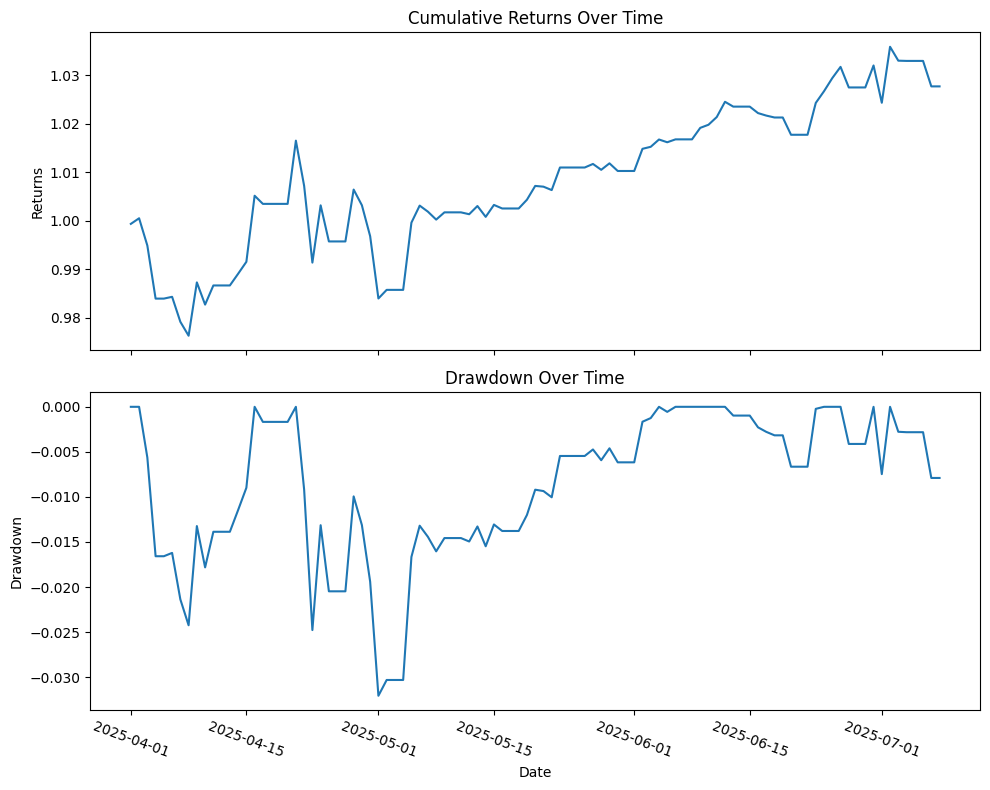

In [ ]:
def compute_portfolio_value(trades_df, price_data_dict):
    """
    Compute daily portfolio value given trades and price data.
    
    trades_df: DataFrame with columns ['date', 'ticker', 'quantity', 'price', 'fees']
    price_data_dict: dict mapping ticker -> DataFrame with index 'date' and column 'close'
    
    Returns:
        portfolio_value: Series indexed by date
    """
    # Ensure date types and sort
    trades = trades_df.copy()
    trades['date'] = pd.to_datetime(trades['date'])
    trades.sort_values('date', inplace=True)

    # Determine date index range
    all_dates = pd.date_range(
        start=trades['date'].min(), 
        end=max(df.index.max() for df in price_data_dict.values()),
        freq='D'
    )
    
    # Initialize cash flow and holdings
    cash_flows = pd.Series(0.0, index=all_dates)
    holdings = {ticker: pd.Series(0.0, index=all_dates) for ticker in price_data_dict if ticker != 'CASH'}
    invested_capital = pd.Series(0.0, index=all_dates)
    
    # Process trades
    for _, row in trades.iterrows():
        dt = row['date']
        tk = row['ticker']
        qty = row['quantity']
        price = row['price']
        fees = row['fees']
        
        if tk == 'CASH':
            cash_flows.loc[dt] += qty
            invested_capital[dt:] += qty
        else:
            # Update holdings from this date onward
            holdings[tk].loc[dt:] += qty
            # Cash change: buying (positive qty) -> outflow; selling (negative qty) -> inflow
            cash_flows.loc[dt] += -qty * price - fees
    
    # Compute cumulative cash
    cash = cash_flows.cumsum()
    
    # Compute daily holdings value
    holdings_value = pd.Series(0.0, index=all_dates)
    for tk, pos in holdings.items():
        # Align prices
        # prices = price_data_dict[tk].reindex(all_dates)['close'].fillna(method='ffill')
        prices = price_data_dict[tk].reindex(all_dates)['close'].ffill()
        holdings_value += pos * prices
    
    # Total portfolio value
    portfolio_value = cash + holdings_value
    return portfolio_value, invested_capital

def compute_performance_metrics(portfolio_value, invested_capital, trading_days=252):
    """
    Compute performance metrics: CAGR, volatility, Sharpe ratio, max drawdown
    """
    cumulative_returns = portfolio_value / invested_capital

    # Daily returns
    daily_returns = cumulative_returns.pct_change().dropna()
    
    # CAGR
    total_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]).days
    cagr = (cumulative_returns.iloc[-1] / cumulative_returns.iloc[0]) ** (trading_days / total_days) - 1
    
    # Volatility (annualized)
    vol = daily_returns.std() * np.sqrt(trading_days)
    
    # Sharpe ratio (assumes risk-free rate = 0)
    sharpe = cagr / vol
    
    # Max drawdown
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    max_dd = drawdown.min()

    print(f'CAGR:                   {cagr:.2%}')
    print(f'Volatility:             {vol:.2%}')
    print(f'Sharpe Ratio:           {sharpe:.2f}')
    print(f'Max Drawdown:          -{-max_dd:.2%}')
    print(f'Total Returns:          {portfolio_value.iloc[-1] / invested_capital.iloc[-1] - 1:.2%}')
    print(f'Total PnL:             ${portfolio_value.iloc[-1] - invested_capital.iloc[-1]:.2f}')
    
    
    return {
        'CAGR': cagr,
        'Volatility': vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd
    }

def plot_portfolio_and_drawdown(portfolio_value, invested_capital):
    """
    Plot portfolio value and drawdown
    """
    cumulative_returns = portfolio_value / invested_capital

    # Compute drawdown
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
    
    ax1.plot(cumulative_returns.index, cumulative_returns.values)
    ax1.set_title('Cumulative Returns Over Time')
    ax1.set_ylabel('Returns')
    
    ax2.plot(drawdown.index, drawdown.values)
    ax2.set_title('Drawdown Over Time')
    ax2.set_ylabel('Drawdown')
    ax2.set_xlabel('Date')
    plt.setp(ax2.get_xticklabels(), rotation=-20)
    
    plt.tight_layout()
    plt.show()

# Example usage:
trades_df = pd.read_excel('portfolio_tracker.xlsx')
# trades_df = trades_df.loc[trades_df['ticker'].isin(['SPY', 'TLT', 'GLD', 'SHV', 'CASH'])]
price_data_dict = {
    'SPY': pd.read_pickle(f'./data/raw/price/SPY_{current_date}.pkl'),
    'TLT': pd.read_pickle(f'./data/raw/price/TLT_{current_date}.pkl'),
    'GLD': pd.read_pickle(f'./data/raw/price/GLD_{current_date}.pkl'),
    'SHV': pd.read_pickle(f'./data/raw/price/SHV_{current_date}.pkl'),
    'PPLT': pd.read_pickle(f'./data/raw/price/PPLT_{current_date}.pkl'),
    'URA': pd.read_pickle(f'./data/raw/price/URA_{current_date}.pkl'),
    'USO': pd.read_pickle(f'./data/raw/price/USO_{current_date}.pkl'),
    'IBIT': pd.read_pickle(f'./data/raw/price/IBIT_{current_date}.pkl'),
    'EEM': pd.read_pickle(f'./data/raw/price/EEM_{current_date}.pkl'),
    'DBA': pd.read_pickle(f'./data/raw/price/DBA_{current_date}.pkl'),
    'IB01.L': pd.read_pickle(f'./data/raw/price/IB01.L_{current_date}.pkl'),
    'LQD': pd.read_pickle(f'./data/raw/price/LQD_{current_date}.pkl'),

}
port_val, invested_cap = compute_portfolio_value(trades_df, price_data_dict)
metrics = compute_performance_metrics(port_val, invested_cap)
plot_portfolio_and_drawdown(port_val, invested_cap)
# for key in metrics:
#     print(f'{key}: {metrics[key]:.2f}')


